In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [ ]:
from src.data.dataset import create_datasets, create_dataloaders

In [3]:
DATA_DIR = "../data/raw"

train_dataset, val_dataset, test_dataset = create_datasets(
    data_dir=DATA_DIR,
    val_split=0.1,
    seed=42
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 25839
Validation size: 2870
Test size: 7178


In [4]:
from torchvision.datasets import ImageFolder

base_train_dataset = ImageFolder(root="../data/raw/train")

print("Classes:", base_train_dataset.classes)
print("Class to index mapping:", base_train_dataset.class_to_idx)

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Class to index mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [5]:
image, label = train_dataset[0]

print("Image type:", type(image))
print("Image shape:", image.shape)
print("Label:", label)

Image type: <class 'torch.Tensor'>
Image shape: torch.Size([1, 48, 48])
Label: 3


Matplotlib is building the font cache; this may take a moment.


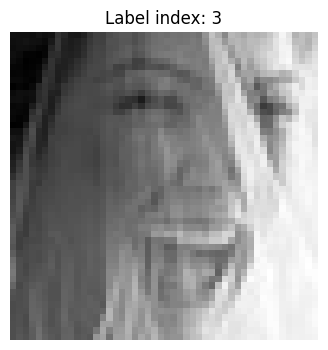

In [6]:
import matplotlib.pyplot as plt

image_for_display = image.squeeze(0).numpy()   # [1, 48, 48] -> [48, 48]
image_for_display = (image_for_display * 0.5) + 0.5  # undo normalization

plt.figure(figsize=(4, 4))
plt.imshow(image_for_display, cmap="gray")
plt.title(f"Label index: {label}")
plt.axis("off")
plt.show()

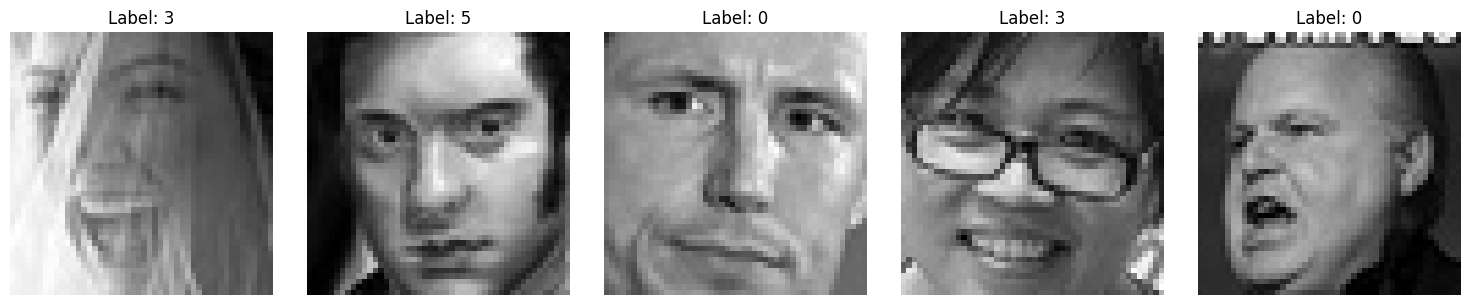

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    image, label = train_dataset[i]
    image = image.squeeze(0).numpy()
    image = (image * 0.5) + 0.5  # undo normalization

    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [8]:
from src.models.baseline_cnn import BaselineCNN

In [9]:
model = BaselineCNN(num_classes=7)
model

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4608, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=7, bias=True)
  )
)

In [10]:
sample_image, sample_label = train_dataset[0]

# Add batch dimension: [1, 48, 48] -> [1, 1, 48, 48]
sample_image = sample_image.unsqueeze(0)

print("Input shape:", sample_image.shape)

output = model(sample_image)

print("Output shape:", output.shape)
print("Output tensor:", output)

Input shape: torch.Size([1, 1, 48, 48])
Output shape: torch.Size([1, 7])
Output tensor: tensor([[-0.0331, -0.0368,  0.0143, -0.0271, -0.0114,  0.0717,  0.0266]],
       grad_fn=<AddmmBackward0>)
